# RansomSense
## Notebook 2: Exploratory Data Analysis (EDA)

### Objective

Exploratory Data Analysis (EDA) is performed to better understand the ransomware dataset before building machine learning models.

This notebook focuses on identifying trends, distributions, relationships, and anomalies within the data.

The insights gained here will guide feature engineering and model selection in the next stages of the project.

### Questions to Answer

- Which industries are attacked the most?
- Which countries experience the highest number of attacks?
- Which ransomware groups are the most active?
- Which attack vectors are most common?
- What is the financial impact of ransomware?
- How severe are most attacks?
- Which variables appear to influence severity?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/cleaned_ransomware_dataset.csv")

df.head()

,Attack_ID,Company_Name,Industry,Country,Attack_Date,Ransomware_Group,Attack_Vector,Ransom_Amount_USD,Payment_Status,Data_Exfiltration,Downtime_Days,Records_Affected,Estimated_Total_Loss_USD,Severity_Score
0,RA-100000,Mcdonald-Smith,Government,United Kingdom,2024-08-02,BlackCat,Drive-by Download,938912,Paid,No,2,2307213,1462487,3.55
1,RA-100001,Lopez and Sons,Transportation,Japan,2021-03-07,LockBit,Credential Theft,254957,Not Paid,No,6,1834168,752882,2.99
2,RA-100002,Anthony Group,Healthcare,United Kingdom,2022-03-28,Ryuk,Malicious Attachment,3773238,Negotiated,Yes,38,2333732,5480736,11.81
3,RA-100003,"Rodriguez, Romero and Mills",Finance,Australia,2022-03-17,Maze,Credential Theft,2828559,Negotiated,Yes,7,778108,3635324,4.66
4,RA-100004,Brown LLC,Technology,South Africa,2025-02-03,Hive,Malicious Attachment,3858935,Negotiated,Yes,35,1047217,5803128,10.16


# Dataset Overview

The cleaned dataset is loaded to verify its structure before beginning exploratory analysis.

In [3]:
df.shape

(5000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attack_ID                 5000 non-null   str    
 1   Company_Name              5000 non-null   str    
 2   Industry                  5000 non-null   str    
 3   Country                   5000 non-null   str    
 4   Attack_Date               5000 non-null   str    
 5   Ransomware_Group          5000 non-null   str    
 6   Attack_Vector             5000 non-null   str    
 7   Ransom_Amount_USD         5000 non-null   int64  
 8   Payment_Status            5000 non-null   str    
 9   Data_Exfiltration         5000 non-null   str    
 10  Downtime_Days             5000 non-null   int64  
 11  Records_Affected          5000 non-null   int64  
 12  Estimated_Total_Loss_USD  5000 non-null   int64  
 13  Severity_Score            5000 non-null   float64
dtypes: float64(1), int6

# Numerical Feature Summary

Descriptive statistics provide an overview of the numerical variables, including their central tendency, spread, and potential outliers.

In [5]:
df.describe()

,Ransom_Amount_USD,Downtime_Days,Records_Affected,Estimated_Total_Loss_USD,Severity_Score
count,5.000000e+03,5000.000000,5.000000e+03,5.000000e+03,5000.000000
mean,2.522979e+06,30.244000,2.485618e+06,3.526212e+06,9.545264
std,1.440345e+06,17.402213,1.450526e+06,1.553324e+06,3.337204
min,5.717000e+03,1.000000,6.020000e+02,5.751200e+04,0.880000
25%,1.287672e+06,15.000000,1.230862e+06,2.291936e+06,7.020000
50%,2.512567e+06,30.000000,2.473088e+06,3.508614e+06,9.580000
75%,3.774430e+06,46.000000,3.734061e+06,4.781601e+06,11.992500
max,4.998740e+06,60.000000,4.996165e+06,6.958310e+06,18.640000


# Categorical Feature Summary

Categorical variables provide information about industries, countries, attack vectors, ransomware groups, and payment status.

In [6]:
df.describe(include="object")

C:\Users\hlaku\AppData\Local\Temp\ipykernel_28372\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Attack_ID,Company_Name,Industry,Country,Attack_Date,Ransomware_Group,Attack_Vector,Payment_Status,Data_Exfiltration
count,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,5000,4562,10,10,1758,10,6,4,2
top,RA-100000,Smith and Sons,Technology,India,2022-03-28,LockBit,Phishing Email,Unknown,No
freq,1,9,531,544,8,521,844,1342,2501


# Distribution of Numerical Variables

Histograms help visualize the distribution of each numerical feature and reveal skewness or unusual values.

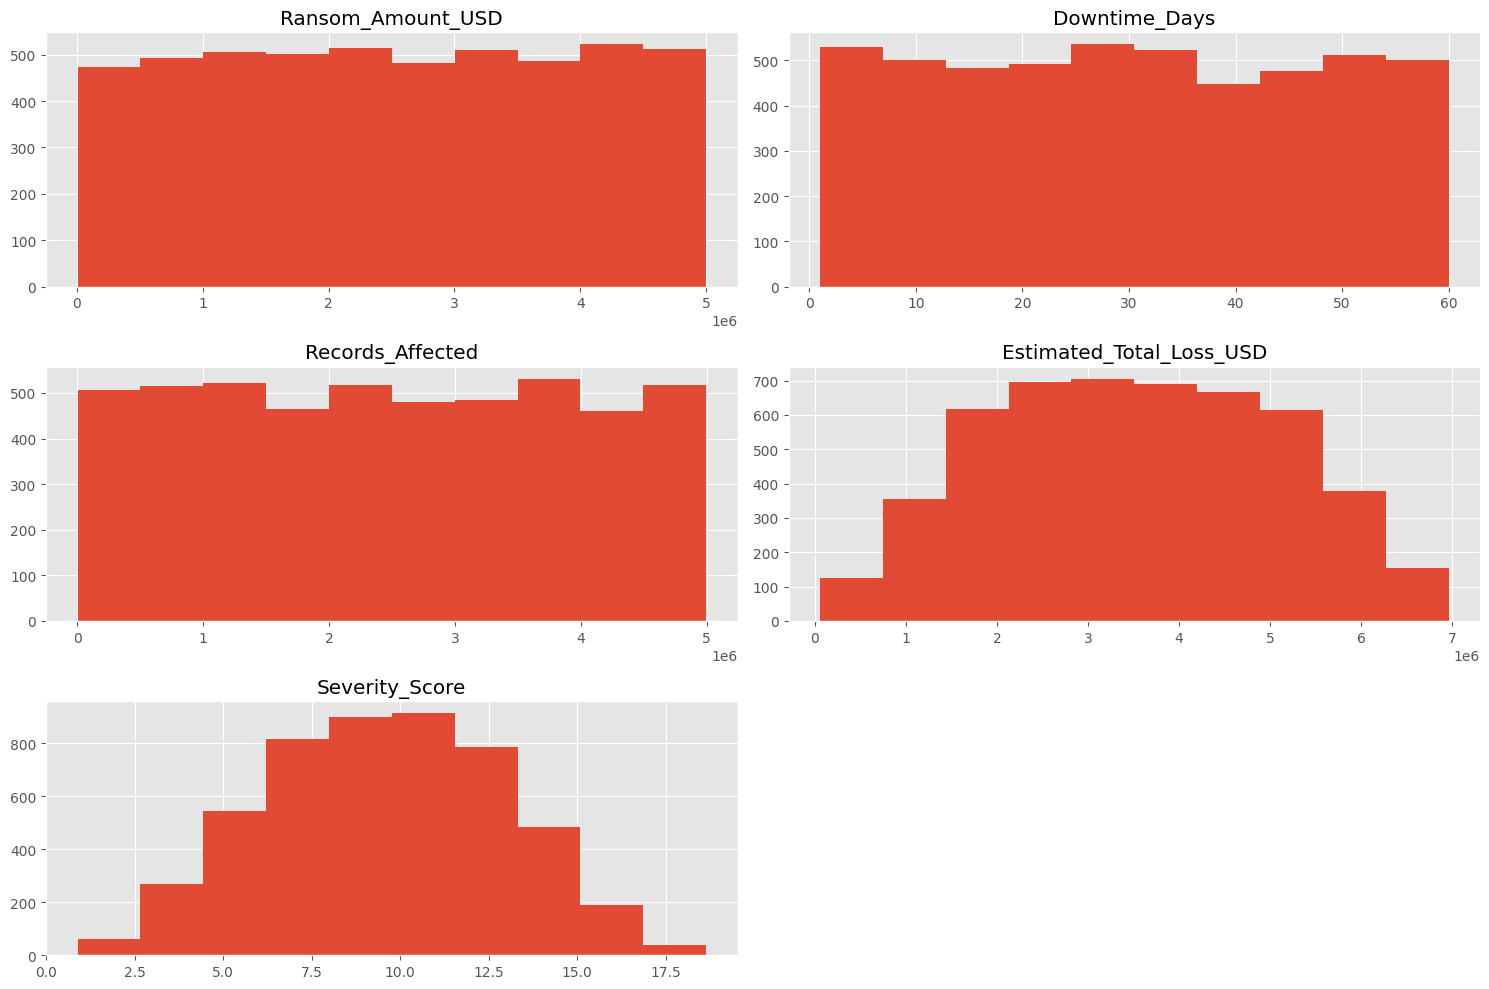

In [7]:
numerical = df.select_dtypes(include=["int64","float64"])

numerical.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

# Distribution of Attacks by Industry

This visualization identifies the industries most frequently targeted by ransomware attacks.

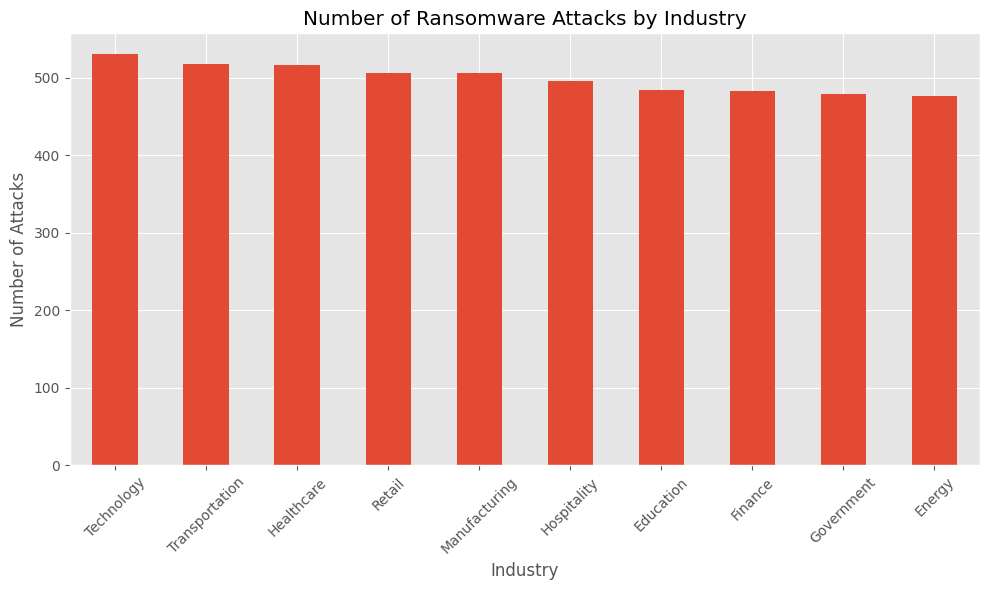

In [8]:
industry = df["Industry"].value_counts()

plt.figure(figsize=(10,6))

industry.plot(kind="bar")

plt.title("Number of Ransomware Attacks by Industry")

plt.xlabel("Industry")

plt.ylabel("Number of Attacks")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/industry_distribution.png", dpi=300)

plt.show()

### Insight

Identify the industries with the highest number of recorded attacks and discuss why these sectors might be attractive targets for ransomware groups.

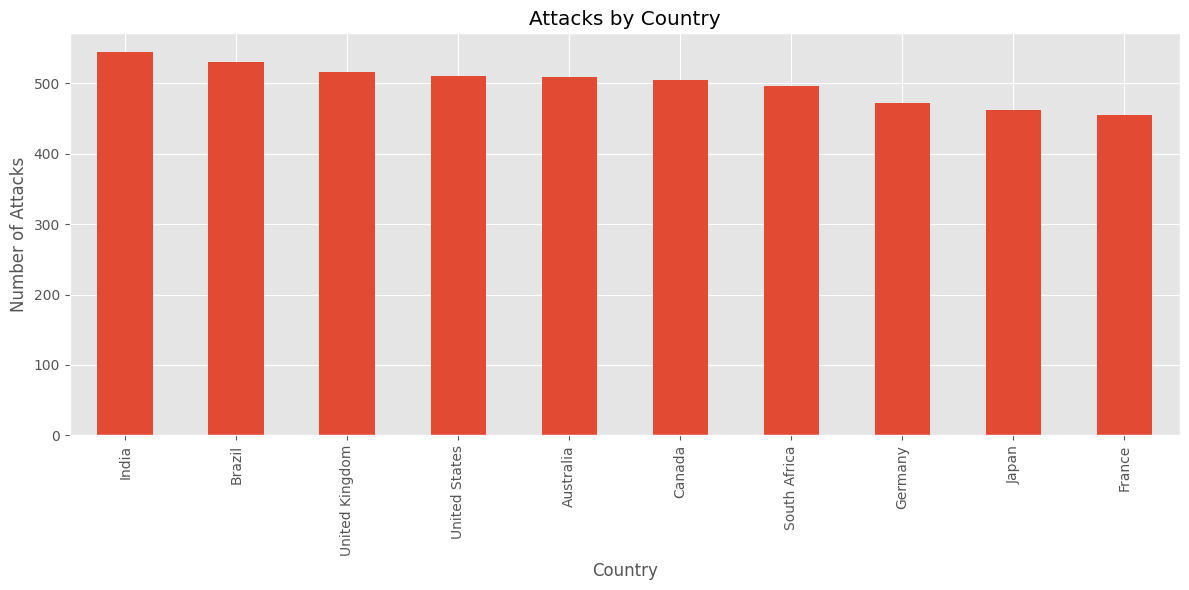

In [9]:
country = df["Country"].value_counts()

plt.figure(figsize=(12,6))

country.plot(kind="bar")

plt.title("Attacks by Country")

plt.xlabel("Country")

plt.ylabel("Number of Attacks")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("../images/country_distribution.png", dpi=300)

plt.show()

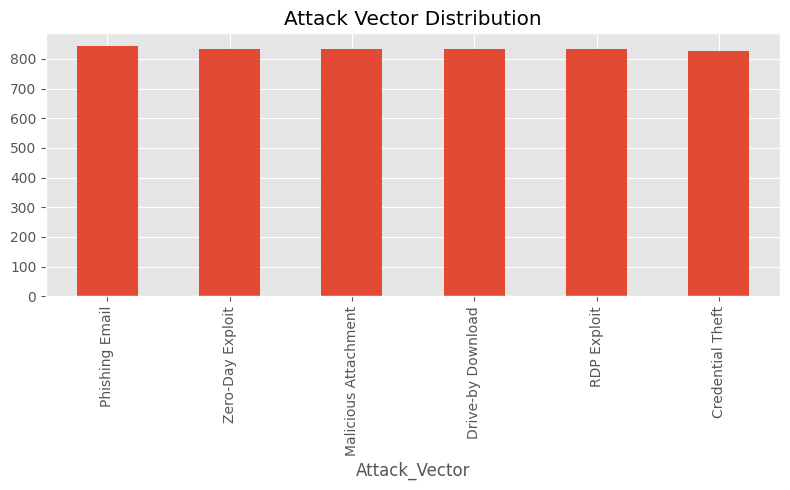

In [10]:
attack = df["Attack_Vector"].value_counts()

plt.figure(figsize=(8,5))

attack.plot(kind="bar")

plt.title("Attack Vector Distribution")

plt.tight_layout()

plt.savefig("../images/attack_vector.png", dpi=300)

plt.show()

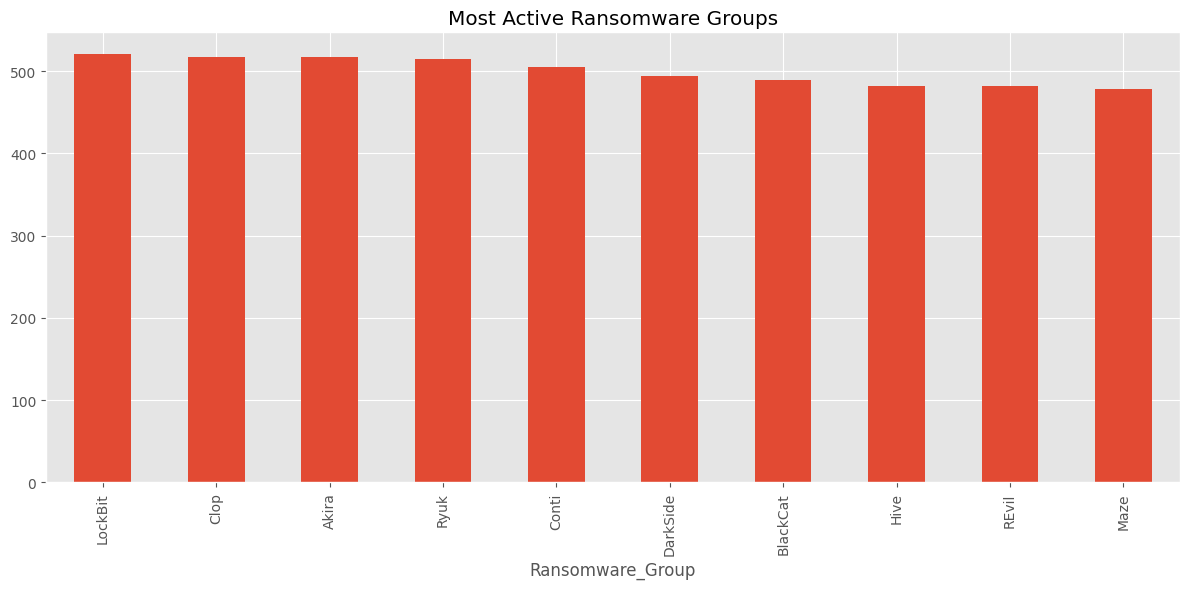

In [11]:
groups = df["Ransomware_Group"].value_counts()

plt.figure(figsize=(12,6))

groups.plot(kind="bar")

plt.title("Most Active Ransomware Groups")

plt.tight_layout()

plt.savefig("../images/ransomware_groups.png", dpi=300)

plt.show()

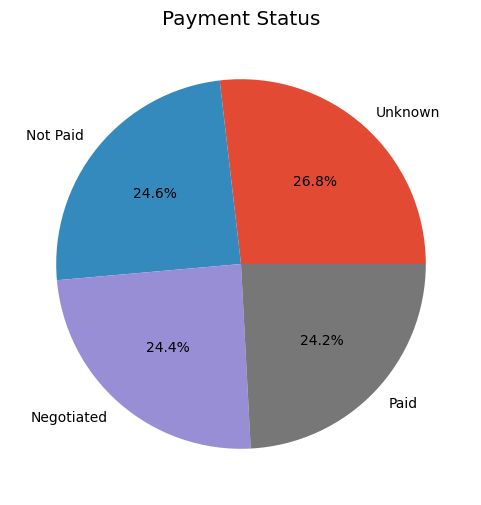

In [12]:
payment = df["Payment_Status"].value_counts()

payment.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Payment Status")

plt.savefig("../images/payment_status.png", dpi=300)

plt.show()

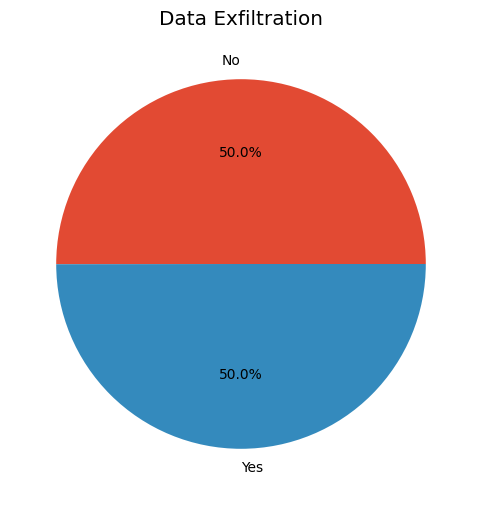

In [13]:
exfiltration = df["Data_Exfiltration"].value_counts()

exfiltration.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Data Exfiltration")

plt.savefig("../images/data_exfiltration.png", dpi=300)

plt.show()

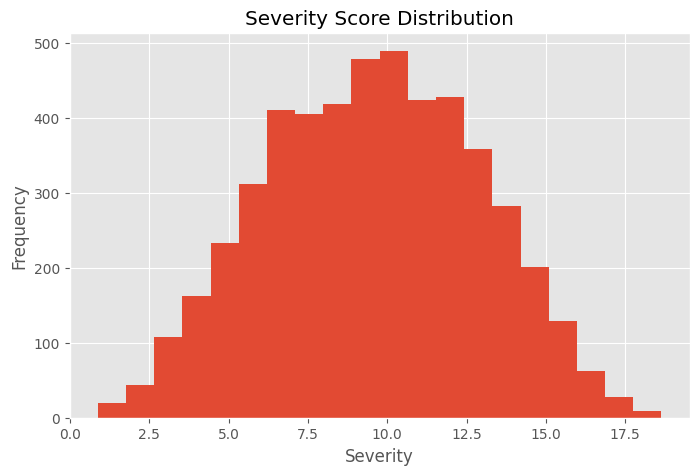

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["Severity_Score"], bins=20)

plt.title("Severity Score Distribution")

plt.xlabel("Severity")

plt.ylabel("Frequency")

plt.savefig("../images/severity_distribution.png", dpi=300)

plt.show()

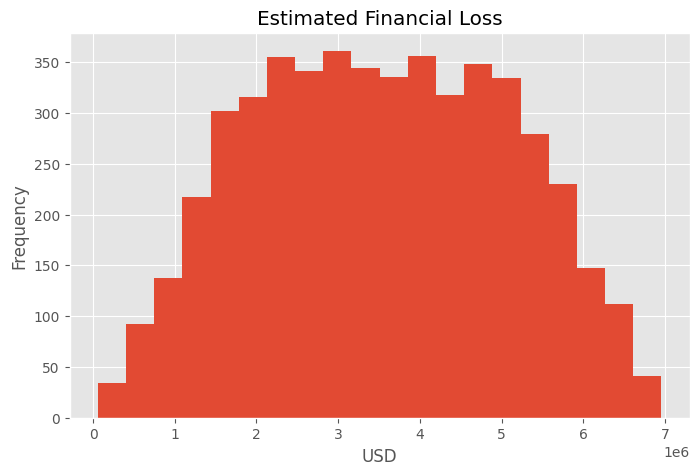

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["Estimated_Total_Loss_USD"], bins=20)

plt.title("Estimated Financial Loss")

plt.xlabel("USD")

plt.ylabel("Frequency")

plt.savefig("../images/loss_distribution.png", dpi=300)

plt.show()

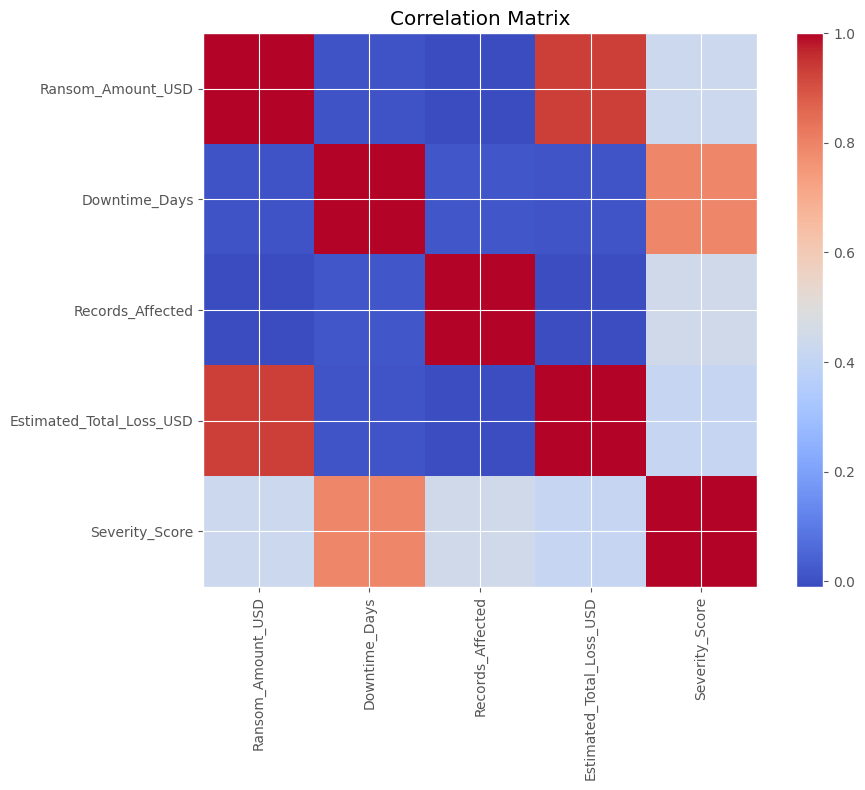

In [16]:
corr = numerical.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig("../images/correlation_matrix.png", dpi=300)

plt.show()

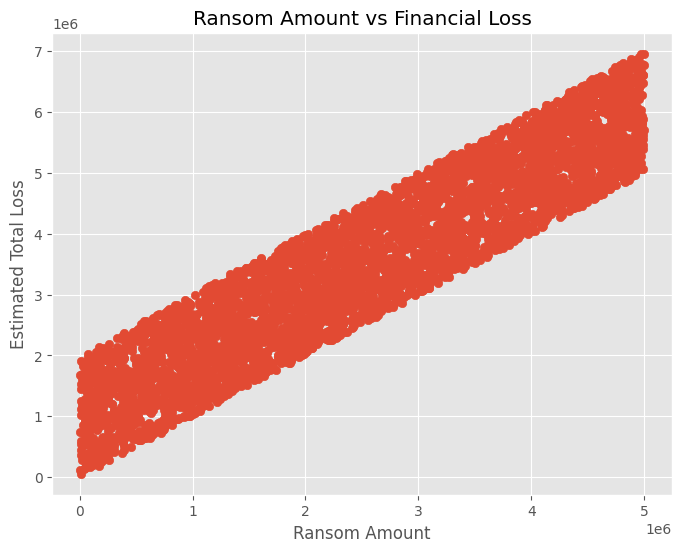

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Ransom_Amount_USD"],
    df["Estimated_Total_Loss_USD"]
)

plt.xlabel("Ransom Amount")

plt.ylabel("Estimated Total Loss")

plt.title("Ransom Amount vs Financial Loss")

plt.savefig("../images/ransom_vs_loss.png", dpi=300)

plt.show()

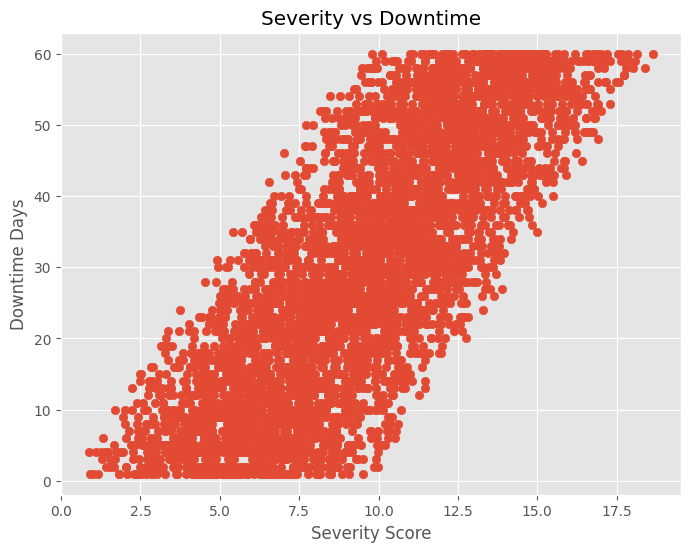

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Severity_Score"],
    df["Downtime_Days"]
)

plt.xlabel("Severity Score")

plt.ylabel("Downtime Days")

plt.title("Severity vs Downtime")

plt.savefig("../images/severity_vs_downtime.png", dpi=300)

plt.show()

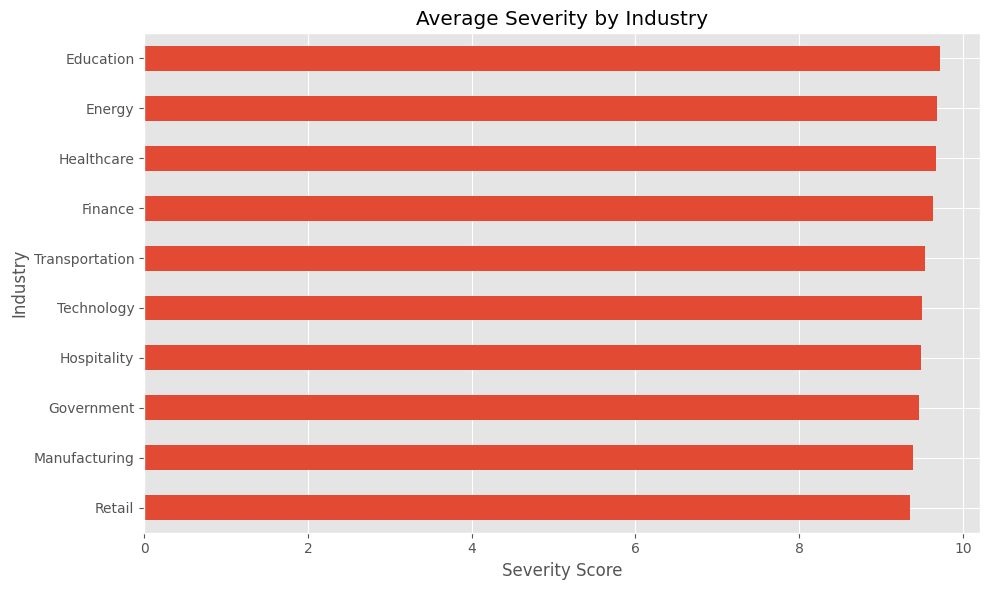

In [19]:
industry_severity = (
    df.groupby("Industry")["Severity_Score"]
        .mean()
        .sort_values()
)

plt.figure(figsize=(10,6))

industry_severity.plot(kind="barh")

plt.title("Average Severity by Industry")

plt.xlabel("Severity Score")

plt.tight_layout()

plt.savefig("../images/industry_severity.png", dpi=300)

plt.show()

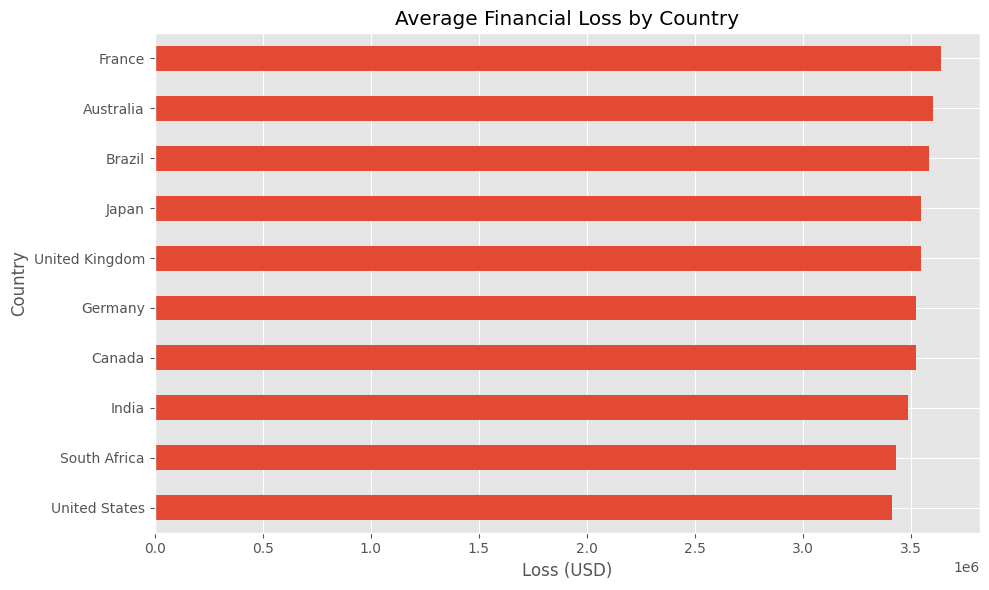

In [20]:
loss_country = (
    df.groupby("Country")["Estimated_Total_Loss_USD"]
        .mean()
        .sort_values()
)

plt.figure(figsize=(10,6))

loss_country.plot(kind="barh")

plt.title("Average Financial Loss by Country")

plt.xlabel("Loss (USD)")

plt.tight_layout()

plt.savefig("../images/loss_country.png", dpi=300)

plt.show()

# Conclusion

This exploratory analysis revealed important patterns in the ransomware dataset, including the distribution of attacks across industries and countries, common attack vectors, financial impacts, and relationships between key variables.

The insights gained from this analysis will inform feature engineering and preprocessing decisions in the next notebook, ensuring that the machine learning models are built on well-understood data.